# Curve Fitting - McClarren, Chapter 11


<img src="Uploaded Media/interp_vs_fit.png">

In the previous chapter we investigated methods that exactly interpolated a set of data. That
is we derived functions that passed through a set of data points. Sometimes it is better to find
a function that does not exactly interpolate the data points. For example, if we did an experiment and we expected the measured value to be linear in some variable x we might write
$$
f(x) = a + bx + \epsilon
$$


where f (x) is the measured value, and ϵ is an error term because the experimental data probably does not fall in exactly a straight line. In this case the ϵ contains the measurement error
and inherent variability in the system. In such a case, rather than performing linear interpolation, we want to find the values of a and b that best match the measured data, but do not
necessarily exactly match the data.


### Another reason 
We might want to find this best match is that there might be another hidden variable we do not know about, but we want to find the best possible model given the
variables we do know about. As an example say we want to know the radiation dose rate
outside of a shield, but there is an unknown source variability, we could write


$$
\log(\text{dose}) = a + b\,(\text{shield thickness}) + \epsilon
$$

where now $\epsilon$ is capturing the error in not including the source variation, as well as the measurement uncertainty.

### One more
In a less scientific example, a retail corporation has stores throughout the country and
wants to know how the area around the store (sometimes called a trade area) and the size of
the store affect the sales at a store. In this case we may write

$$
\text{Sales} = a 
+ b\,\text{(Population within 5 minute drive of store)} 
+ c\,\text{(Size of Store)} 
+ \epsilon
$$

In this case there may be hundred of hidden variables such as the presence of competition in
the market, the age of the store, or the time of year.


## The question that we are faced with 

We have <u>set of input variables</u> and the value of
<u>an output variable at several points</u>, and we want to fit a linear model to this data. By linear
model we mean a function that is the sum of contributions from each input or some operation
on the inputs. 

Note: The model is linear in the unknown parameters (coefficients).



# 11.1 Fitting a simple line


To proceed, we will take some data and try to fit a linear model to the data. Along the way
we will see that the problem is not well-posed, and demonstrate a means to give it a unique
solution.


| x | y        |
|---|----------|
| 1 | 11.94688 |
| 2 | 22.30126 |
| 3 | 32.56929 |
| 4 | 41.65564 |


and we want to fit a model

$$
y = a + bx
$$


What we can do is write this as a linear system of equations, where the unknowns are

$$
\mathbf{u} =
\begin{pmatrix}
a \\
b
\end{pmatrix}.
$$

That is, we want to solve for $\mathbf{u}$ in the equation

$$
X\mathbf{u} = \mathbf{y}.
$$


where $X$ is the data matrix,

$$
X =
\begin{pmatrix}
1 & 1 \\
1 & 2 \\
1 & 3 \\
1 & 4
\end{pmatrix},
$$

and $\mathbf{y}$ is the vector of dependent variables,

$$
\mathbf{y} =
\begin{pmatrix}
11.94688 \\
22.30126 \\
32.56929 \\
41.65564
\end{pmatrix}.
$$


Putting in our data values, our system gives

$$
\begin{pmatrix}
1 & 1 \\
1 & 2 \\
1 & 3 \\
1 & 4
\end{pmatrix}
\begin{pmatrix}
a \\
b
\end{pmatrix}
=
\begin{pmatrix}
11.94688 \\
22.30126 \\
32.56929 \\
41.65564
\end{pmatrix}.
$$

To make the problem well-posed, we multiply both sides of the equation
by the transpose of the matrix $X$:

$$
X^T X \mathbf{u} = X^T \mathbf{y}.
$$

That is,

$$
\begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & 2 & 3 & 4
\end{pmatrix}
\begin{pmatrix}
1 & 1 \\
1 & 2 \\
1 & 3 \\
1 & 4
\end{pmatrix}
\begin{pmatrix}
a \\
b
\end{pmatrix}
=
\begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & 2 & 3 & 4
\end{pmatrix}
\begin{pmatrix}
11.94688 \\
22.30126 \\
32.56929 \\
41.65564
\end{pmatrix}.
$$


In [1]:
import numpy as np
A = np.array([(1,1),(1,2),(1,3),(1,4)])
RHS = np.array([11.94688, 22.30126, 32.56929, 41.65564])
print("The system A x = b has A =\n",A)
print("And b =",RHS)



The system A x = b has A =
 [[1 1]
 [1 2]
 [1 3]
 [1 4]]
And b = [11.94688 22.30126 32.56929 41.65564]


In [2]:
AT_times_A = np.dot(A.transpose(),A)
AT_times_RHS = np.dot(A.transpose(),RHS)
print("The system after multiplying by A transpose is A^T A =\n",AT_times_A)
print("A^T b =",AT_times_RHS)

The system after multiplying by A transpose is A^T A =
 [[ 4 10]
 [10 30]]
A^T b = [108.47307 320.87983]


Now we have a two-by-two system that we can solve:

$$
\begin{pmatrix}
4 & 10 \\
10 & 30
\end{pmatrix}
\mathbf{u}
=
\begin{pmatrix}
108.47307 \\
320.87983
\end{pmatrix},
\qquad
\text{where }
\mathbf{u}=
\begin{pmatrix}
a \\
b
\end{pmatrix}.
$$


This system is known as the “normal equations”. We will solve this system with the Gaus-
sian elimination

In [3]:
from GaussElimPivotSolve import GaussElimPivotSolve

ab = GaussElimPivotSolve(AT_times_A,AT_times_RHS)
print("The constant a =",ab[0]," with a slope of b =",ab[1])




The constant a = 2.2696900000000255  with a slope of b = 9.93943099999999


<img src="Uploaded Media/11.1.png">

To get a measure of how this model fits the data we look at a quantity called $R^2$ (pronounced “R-squared”), defined as

$$
R^2
=
1 -
\frac{
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
}{
\sum_{i=1}^{n} (y_i - \bar{y})^2
}.
$$


where $\hat{y}_i$ is the $i^{\text{th}}$ predicted data point from the model.



$$
\hat{y}_i = \mathbf{x}_i \cdot \mathbf{u} = a + b x_i,
$$

and $\bar{y}$ is the mean of the observed data.

Notice that in the definition of $\mathbf{x}_i$ we include a 1 to handle
the intercept term:

$$
\mathbf{x}_i =
\begin{pmatrix}
1 \\
x_i
\end{pmatrix}.
$$

In [33]:
yhat = ab[0] + ab[1]*A[:,1]
print("yhat =\t",yhat)
print("y =\t",RHS)
residual = yhat - RHS
print("error =\t",residual)
r2Num = np.sum(residual**2)
r2Denom = np.sum((RHS-RHS.mean())**2)
print("R2 numerator =", r2Num)
print("R2 denominator =", r2Denom)
r2 = 1 - r2Num/r2Denom
print("R2 =", r2)

yhat =	 [12.209121 22.148552 32.087983 42.027414]
y =	 [11.94688 22.30126 32.56929 41.65564]
error =	 [ 0.262241 -0.152708 -0.481307  0.371774]
R2 numerator = 0.46196241067000493
R2 denominator = 494.423405429475
R2 = 0.9990656542437171


A perfect $R^2$ value is 1. Sometimes $R^2$ is described as the
*fraction of variance explained* by the model. Therefore,
an $R^2$ of 1 (or 100%) implies that 100% of the variability
in the observed data is explained by the model.

A value of $R^2 = 0.999$, as in this fit, is extremely high and
typically appears only in carefully constructed or contrived
data sets used for instructional purposes.

## Least-Squares Regression


Why did we multiply by the transpose of the matrix?

Multiplying both sides of the equation by $X^T$ gives the
normal equations

$$
X^T X \mathbf{u} = X^T \mathbf{y}.
$$

Besides producing a square system that we can solve, this
procedure has an important meaning: it minimizes the total
squared error

$$
E = \sum_{i=1}^{n} (\hat{y}_i - y_i)^2.
$$

That is, the solution obtained from the normal equations is
the vector $\mathbf{u}$ that makes $E$ as small as possible.

This is why the method is called *least-squares regression (a.k.a. L2 Regression)* —
it finds the coefficients that minimize the sum of the squares
of the errors at each data point.

We can show that our solution gives the minimum (least) squared error
by differentiating the error function with respect to $\mathbf{u}$
and setting the result equal to zero.

The squared error is

$$
E(\mathbf{u}) = \sum_{i=1}^{n} (\mathbf{x}_i \cdot \mathbf{u} - y_i)^2.
$$

Taking the derivative with respect to $\mathbf{u}$ gives

$$
\frac{dE}{d\mathbf{u}}
=
2 \sum_{i=1}^{n}
\mathbf{x}_i \, (\mathbf{x}_i^{T}\mathbf{u} - y_i).
$$

Setting the derivative equal to zero,

$$
2 \sum_{i=1}^{n}
\mathbf{x}_i \, (\mathbf{x}_i^{T}\mathbf{u} - y_i)
=
0.
$$

which, upon rearranging and using the definition of matrix–vector
multiplication, leads to the normal equations

$$
X^T X \mathbf{u} = X^T \mathbf{y}.
$$

Thus, the value of $\mathbf{u}$ is found by multiplying the system
by the transpose of $X$. This is the equation we solve to estimate
the coefficients in the model.

Least-squares regression has the important property that the sum
of the residuals is zero:

$$
\sum_{i=1}^{n} (y_i - \hat{y}_i) = 0.
$$

It works particularly well when the errors in the data
(that is, the deviations from the model) are independent random
variables with mean zero and constant variance, and do not depend
on the values of the independent variables.


## Recap

To proceed, we will take some data and try to fit a linear model to the data. Along the way
we will see that the problem is not well-posed, and demonstrate a means to give it a unique
solution.


| x | y        |
|---|----------|
| 1 | 11.94688 |
| 2 | 22.30126 |
| 3 | 32.56929 |
| 4 | 41.65564 |


and we want to fit a model

$$
y = a + bx
$$


What we can do is write this as a linear system of equations, where the unknowns are

$$
\mathbf{u} =
\begin{pmatrix}
a \\
b
\end{pmatrix}.
$$

That is, we want to solve for $\mathbf{u}$ in the equation

$$
X\mathbf{u} = \mathbf{y}.
$$


where $X$ is the data matrix,

$$
X =
\begin{pmatrix}
1 & 1 \\
1 & 2 \\
1 & 3 \\
1 & 4
\end{pmatrix},
$$

and $\mathbf{y}$ is the vector of dependent variables,

$$
\mathbf{y} =
\begin{pmatrix}
11.94688 \\
22.30126 \\
32.56929 \\
41.65564
\end{pmatrix}.
$$


Putting in our data values, our system gives

$$
\begin{pmatrix}
1 & 1 \\
1 & 2 \\
1 & 3 \\
1 & 4
\end{pmatrix}
\begin{pmatrix}
a \\
b
\end{pmatrix}
=
\begin{pmatrix}
11.94688 \\
22.30126 \\
32.56929 \\
41.65564
\end{pmatrix}.
$$

To make the problem well-posed, we multiply both sides of the equation
by the transpose of the matrix $X$:

$$
X^T X \mathbf{u} = X^T \mathbf{y}.
$$

That is,

$$
\begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & 2 & 3 & 4
\end{pmatrix}
\begin{pmatrix}
1 & 1 \\
1 & 2 \\
1 & 3 \\
1 & 4
\end{pmatrix}
\begin{pmatrix}
a \\
b
\end{pmatrix}
=
\begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & 2 & 3 & 4
\end{pmatrix}
\begin{pmatrix}
11.94688 \\
22.30126 \\
32.56929 \\
41.65564
\end{pmatrix}.
$$

<img src="Uploaded Media/11.1.png">



To get a measure of how this model fits the data we look at a quantity called $R^2$ (pronounced “R-squared”), defined as

$$
R^2
=
1 -
\frac{
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
}{
\sum_{i=1}^{n} (y_i - \bar{y})^2
}.
$$


where $\hat{y}_i$ is the $i^{\text{th}}$ predicted data point from the model.


Why did we multiply by the transpose of the matrix?

Multiplying both sides of the equation by $X^T$ gives the
normal equations

$$
X^T X \mathbf{u} = X^T \mathbf{y}.
$$

Besides producing a square system that we can solve, this
procedure has an important meaning: it minimizes the total
squared error

$$
E = \sum_{i=1}^{n} (\hat{y}_i - y_i)^2.
$$

This is why the method is called *least-squares regression (a.k.a. L2 Regression)* —
it finds the coefficients that minimize the sum of the squares
of the errors at each data point.





## 11.2 Multiple Linear Regression

We generalize fitting a linear function to data to allow for multiple independent variables.

Consider \(I\) observations of a dependent variable \(y\) and independent variables
$$
\mathbf{x} = (1, x_1, x_2, \ldots, x_J)^T .
$$

We desire to fit a linear model of the form
$$
y(\mathbf{x}) = a_0 + a_1 x_1 + \cdots + a_J x_J + \varepsilon .
$$

The equations that govern the relationship between $y$ and $\mathbf{x}$ are given by
$$
X\mathbf{u} = \mathbf{y},
$$
where $X$ is an $I \times (J+1)$ matrix of the form
$$
X =
\begin{pmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1J} \\
1 & x_{21} & x_{22} & \cdots & x_{2J} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{i1} & x_{i2} & \cdots & x_{iJ} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{I1} & x_{I2} & \cdots & x_{IJ}
\end{pmatrix}.
$$

where the notation $x_{ij}$ denotes the $i$-th observation of the $j$-th independent variable.


$$
\mathbf{u} = (a_0, a_1, \ldots, a_J)^T .
$$




For this example we will use the points scored as the dependent variable with a single independent variable: yards gained. The data in Table 11.1 has been stored in a csv file that is read
in the next code block.

<img src="Uploaded Media/Table11.1.png">

In [6]:
import csv
import numpy as np

with open('FootballScores.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)

    opponent = []
    Yards = np.array([])
    Points = np.array([])
    OffTurn = np.array([])
    DefTurn = np.array([])
    for row in reader:
        #print(row)
        opponent.append(row['Opponent'])
        Yards = np.append(Yards,float(row['Yards Gained']))
        Points = np.append(Points,float(row['Points Scored']))
        OffTurn = np.append(OffTurn,float(row['Off Turnovers']))
        DefTurn = np.append(DefTurn,float(row['Def Turnovers']))
                                          
print(opponent)
print(Yards)
print(Points)
print(OffTurn)
print(DefTurn)

['Rice', 'Sam Houston State', 'Alabama', 'SMU', 'Arkansas', 'Ole Miss', 'Auburn', 'Vanderbilt', 'UTEP', 'Mississippi State', 'LSU', 'Missouri', 'Duke']
[486. 714. 628. 581. 523. 587. 602. 558. 564. 537. 299. 379. 541.]
[52. 65. 42. 42. 45. 41. 41. 56. 57. 51. 10. 21. 52.]
[1. 1. 2. 1. 0. 2. 2. 5. 1. 3. 2. 1. 0.]
[2. 2. 1. 3. 2. 1. 1. 3. 4. 1. 0. 0. 2.]


Now we want to perform our least squares procedure where the independent variable is
yards gained and the dependent variable is points scored. First, we build the matrix as before.
This is a good opportunity to use the vstackfunction in NumPy to stack two vectors on top
of each other and then take the transpose to get a rectangular matrix with 13 rows and 2
columns:

In [7]:
A = np.vstack([np.ones(Yards.size), Yards]).transpose()
print("The A matrix is\n",A)

The A matrix is
 [[  1. 486.]
 [  1. 714.]
 [  1. 628.]
 [  1. 581.]
 [  1. 523.]
 [  1. 587.]
 [  1. 602.]
 [  1. 558.]
 [  1. 564.]
 [  1. 537.]
 [  1. 299.]
 [  1. 379.]
 [  1. 541.]]


NumPy also has a built-in least squares function linalg.lstsq. This function is used by
passing it the data matrix and the righthand side. We use this function to determine the linear
model for points scored as a function of yards gained:

In [8]:
solution = np.linalg.lstsq(A,Points)[0]
print("The function is Points =",solution[0],"+",solution[1],"* Yards")

The function is Points = -16.25775023823457 + 0.11235187213845543 * Yards


$$
\begin{aligned}
&\textbf{Returns}\\[6pt]
&\textbf{x}:\ \{(N,), (N,K)\}\ \text{ndarray}\\
&\qquad \text{Least-squares solution. If } b \text{ is two-dimensional, the solutions are in the } K \text{ columns of } x.\\[8pt]
&\textbf{residuals}:\ \{(1,), (K,), (0,)\}\ \text{ndarray}\\
&\qquad \text{Sums of squared residuals: squared Euclidean 2-norm for each column in }(b-a x).\\
&\qquad \text{If rank}(a)<N \text{ or } M\le N,\ \text{this is an empty array.}\\
&\qquad \text{If } b \text{ is 1-dimensional, the shape is }(1,);\ \text{otherwise the shape is }(K,).\\[8pt]
&\textbf{rank}:\ \text{int}\\
&\qquad \text{Rank of matrix } a.\\[8pt]
&\textbf{s}:\ (\min(M,N),)\ \text{ndarray}\\
&\qquad \text{Singular values of } a.
\end{aligned}
$$


It is important to interpret what the coefficients in your model mean. In this case the model
says that for every 10 yards gained, we expect to score 1.1 points. It also says that if zero yards
are gained, then we expect−16 points to be scored. This seemingly anomalous result arises
because we are trying to fit a simple model to this data. The original data and model are
plotted next to help illustrate what the model is telling us:

The function is Points = -16.25775023823457 + 0.11235187213845543 * Yards

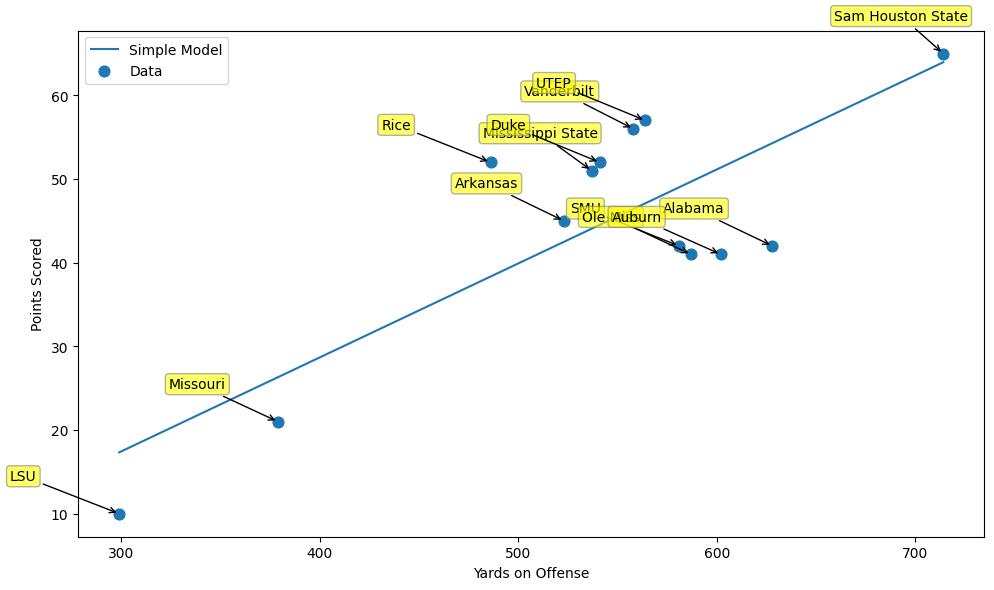

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data (from the table / your CSV arrays) ---
opponent = ['Rice','Sam Houston State','Alabama','SMU','Arkansas',
            'Ole Miss','Auburn','Vanderbilt','UTEP','Mississippi State',
            'LSU','Missouri','Duke']

Yards  = np.array([486,714,628,581,523,587,602,558,564,537,299,379,541], dtype=float)
Points = np.array([ 52, 65, 42, 42, 45, 41, 41, 56, 57, 51, 10, 21, 52], dtype=float)

# --- Simple linear model: Points = a + b*Yards ---
A = np.column_stack([np.ones_like(Yards), Yards])   # [1, x]
coef, *_ = np.linalg.lstsq(A, Points, rcond=None)
a, b = coef

# Line for plotting
xline = np.linspace(Yards.min(), Yards.max(), 200)
yline = a + b*xline

# --- Plot ---
plt.figure(figsize=(10,6))
plt.plot(xline, yline, label='Simple Model')
plt.scatter(Yards, Points, s=60, label='Data')

plt.xlabel('Yards on Offense')
plt.ylabel('Points Scored')

# Labels with yellow boxes + arrows (like your figure)
for name, x, y in zip(opponent, Yards, Points):
    plt.annotate(
        name,
        xy=(x, y),
        xytext=(x-55, y+4),  # offset for label placement
        bbox=dict(boxstyle='round,pad=0.25', fc='yellow', ec='gray', alpha=0.6),
        arrowprops=dict(arrowstyle='->', lw=1),
    )

plt.legend()
plt.tight_layout()
plt.show()

This is what real data typically look like: a lot messier than a simple line with a little noise.
The model shows that several games with very high or very low yards set the trend for the
line. Also we notice that half of the data are on one side of the line and the other half are on
the other. This splitting of the data is typical of least-squares regression.

To adjust our model, we can remove two of the lower conference schools (Sam Houston
State and UTEP); the scores in these games are expected to be different than the other games
based on the strength of those teams. This removes two data points to the top right. Removing
data points like this can help a model if we think that the data removed is not representative
of the overall data set.

In [12]:
Asmall = A[(0,2,3,4,5,6,7,9,10,11,12),:]
PointsSmall = Points[[0,2,3,4,5,6,7,9,10,11,12]]
solution = np.linalg.lstsq(Asmall,PointsSmall)[0]
print("The function is Points =",solution[0],"+",solution[1],"* Yards")

The function is Points = -13.900235706492918 + 0.10590851123429854 * Yards


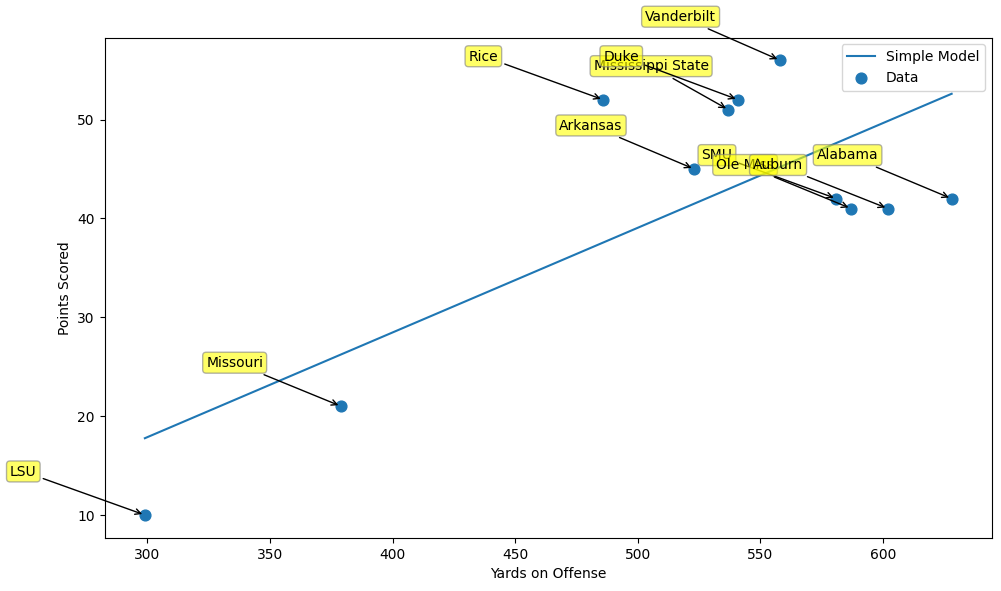

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data (from the table / your CSV arrays) ---
opponent = ['Rice','Alabama','SMU','Arkansas',
            'Ole Miss','Auburn','Vanderbilt','Mississippi State',
            'LSU','Missouri','Duke']

Yards  = np.array([486,628,581,523,587,602,558,537,299,379,541], dtype=float)
Points = np.array([ 52, 42, 42, 45, 41, 41, 56, 51, 10, 21, 52], dtype=float)

# --- Simple linear model: Points = a + b*Yards ---
A = np.column_stack([np.ones_like(Yards), Yards])   # [1, x]
coef, *_ = np.linalg.lstsq(A, Points, rcond=None)
a, b = coef

# Line for plotting
xline = np.linspace(Yards.min(), Yards.max(), 200)
yline = a + b*xline

# --- Plot ---
plt.figure(figsize=(10,6))
plt.plot(xline, yline, label='Simple Model')
plt.scatter(Yards, Points, s=60, label='Data')

plt.xlabel('Yards on Offense')
plt.ylabel('Points Scored')

# Labels with yellow boxes + arrows (like your figure)
for name, x, y in zip(opponent, Yards, Points):
    plt.annotate(
        name,
        xy=(x, y),
        xytext=(x-55, y+4),  # offset for label placement
        bbox=dict(boxstyle='round,pad=0.25', fc='yellow', ec='gray', alpha=0.6),
        arrowprops=dict(arrowstyle='->', lw=1),
    )

plt.legend()
plt.tight_layout()
plt.show()

Notice that the slope of our line did not change much by removing some data (0.112 points
per yard versus 0.106). This is a useful observation. It means that our model is robust to
removing some games. Had the result changed drastically we should be worried that the
model was driven by just a few data points.

### 11.2.2 Adding More Variables

To attempt to improve this model we could add more independent variables. For example, the number of turnovers produced by the defense (i.e., interceptions or fumbles that the
opponent gives up) or given up by the offense (throwing an interception or losing a fumble
by the offense) could also be important. The next figure colors the dots with the number of
turnovers taken by the defense, and the size of the dot is the number of turnovers given up
by the offense. Looking at this chart seems to indicate that the lower scoring games had fewer
turnovers produced by the defense


['Rice', 'Sam Houston State', 'Alabama', 'SMU', 'Arkansas', 'Ole Miss', 'Auburn', 'Vanderbilt', 'UTEP', 'Mississippi State', 'LSU', 'Missouri', 'Duke']
[486. 714. 628. 581. 523. 587. 602. 558. 564. 537. 299. 379. 541.]
[52. 65. 42. 42. 45. 41. 41. 56. 57. 51. 10. 21. 52.]
[1. 1. 2. 1. 0. 2. 2. 5. 1. 3. 2. 1. 0.]
[2. 2. 1. 3. 2. 1. 1. 3. 4. 1. 0. 0. 2.]
The A matrix is
 [[  1. 486.   1.   2.]
 [  1. 714.   1.   2.]
 [  1. 628.   2.   1.]
 [  1. 581.   1.   3.]
 [  1. 523.   0.   2.]
 [  1. 587.   2.   1.]
 [  1. 602.   2.   1.]
 [  1. 558.   5.   3.]
 [  1. 564.   1.   4.]
 [  1. 537.   3.   1.]
 [  1. 299.   2.   0.]
 [  1. 379.   1.   0.]
 [  1. 541.   0.   2.]]
The function is Points = -10.294646698915187 + 0.08263563380258458 * Yards + 0.3769619225927822 * Off Turnovers + 5.570336623961824 * Def Turnovers


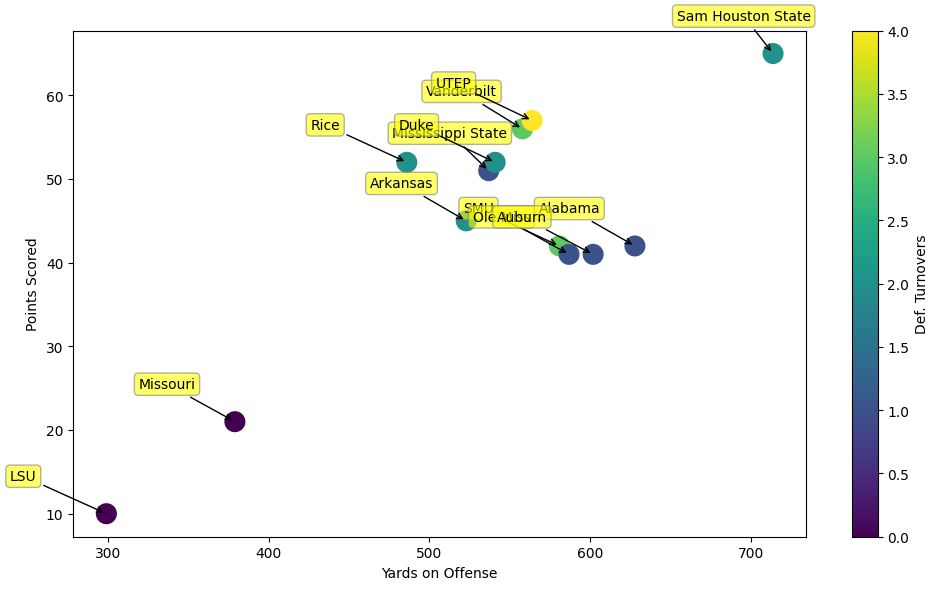

In [ ]:
import csv
import numpy as np

with open('FootballScores.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)

    opponent = []
    Yards = np.array([])
    Points = np.array([])
    OffTurn = np.array([])
    DefTurn = np.array([])
    for row in reader:
        #print(row)
        opponent.append(row['Opponent'])
        Yards = np.append(Yards,float(row['Yards Gained']))
        Points = np.append(Points,float(row['Points Scored']))
        OffTurn = np.append(OffTurn,float(row['Off Turnovers']))
        DefTurn = np.append(DefTurn,float(row['Def Turnovers']))
                                          
print(opponent)
print(Yards)
print(Points)
print(OffTurn)
print(DefTurn)


A = np.vstack([np.ones(Yards.size), Yards, OffTurn, DefTurn]).transpose()
print("The A matrix is\n",A)
solution = np.linalg.lstsq(A,Points)[0]
print("The function is Points =",solution[0],
"+",solution[1],"* Yards","+",solution[2],
"* Off Turnovers","+",solution[3],"* Def Turnovers")



In [ ]:

import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(10,6))

# Scatter plot colored by Defensive Turnovers
sc = plt.scatter(Yards, Points, 
                 c=DefTurn, 
                 s=200, 
                 cmap='viridis')

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Def. Turnovers')

# Axis labels
plt.xlabel('Yards on Offense')
plt.ylabel('Points Scored')

# Annotate each point
for i in range(len(opponent)):
    plt.annotate(opponent[i],
    xy=(Yards[i], Points[i]),
    xytext=(Yards[i]-60, Points[i]+4),
    bbox=dict(boxstyle='round,pad=0.3',
                           fc='yellow',
                           ec='gray',
                           alpha=0.6),
    arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.show()



Once again, we will try to interpret the coefficients in the model. Given the sign of the
coefficient for offensive turnovers, the model indicates that turning over the ball on offense is
actually good for scoring points. Even a basic understanding of football indicates that this is
not likely to be a good strategy. When you get a model with an obviously wrong (or indefensible coefficient), it is best to remove that coefficient and refit the model. The reason we can
get coefficients with strange values is that the model does not tell us what causes the dependent variable to change, it is simply telling us what is correlated with the dependent variable.
To get at causation we would have to do a controlled experiment, not look at historical, observational data such as this data set.

Before we remove the offending independent variable from the mode, we will look at the
values of the predictions versus the actual values. This is an important diagnostic for multivariate models because it is harder to visualize the trends like we did for a single variable
model. We make a scatter plot where the x axis is the actual points scored and the y axis is the
predicted points scored. If the model is perfect, then all the points will fall on the diagonal
line y= x.

<img src="Uploaded Media/figure11.2.2.png">

This figure indicates that our model does seem to predict the number of points scored
based on the independent variables. To get a more quantitative measure of the model accuracy we will compute the average amount the model is off by. This quantity is the average
absolute value of the error, which is simply called the mean absolute error. For this model the
mean absolute error is

In [17]:
yhat = np.dot(A,solution)
np.mean(np.fabs(Points-yhat))

np.float64(5.320173467252322)

We have to compute the average absolute error because of error cancellation — if we computed the average error, the cancellation of positive and negative errors would give us an
average error very close to zero. Indeed this is what we see:

In [18]:
np.mean(Points-yhat)

np.float64(-4.53654208216064e-14)

As indicated above, we should remove offensive turnovers from the model because the
coefficient for this variable did not make sense. We will remove this variable, refit the model,
and plot the actual versus predicted values.

In [19]:
A = np.vstack([np.ones(Yards.size), Yards, DefTurn]).transpose()
solution = np.linalg.lstsq(A,Points)[0]
print("The function is Points =",solution[0],"+",solution[1],"* Yards","+",solution[2],"* Def Turnovers")

The function is Points = -9.790279844475203 + 0.08290360350412988 * Yards + 5.546878047855069 * Def Turnovers


The coefficients of this model indicate that an additional defensive turnover is worth about
5.5 points on offense and that each 10 yards gained is worth 0.8 points. The actual versus predicted values plot looks very similar to the previous model. Additionally, the mean absolute
error is about the same.

In [20]:
np.mean(np.fabs(Points-yhat))

np.float64(5.320173467252322)

The $R^2$ for this model is

In [21]:
1-np.sum((Points-yhat)**2)/np.sum((Points.mean() - Points)**2)

np.float64(0.791842921723684)

## 11.3 'Nonlinear' Models

Least-squares regression can be applied to models that are nonlinear in the independent
variables, if we can map the nonlinearity to new independent variables. In this section we
demonstrate this procedure.

Suppose we wish to fit a model of the form
$$
f(x)= a_0 + a_1 x_1 + a_2 x_1^2 .
$$

We can fit this model using least squares by defining a new variable
$$
x_2 \equiv x_1^2 .
$$

This makes the model look like a multivariate regression model:
$$
f(x)= a_0 + a_1 x_1 + a_2 x_2 .
$$

Therefore, to fit this quadratic model we set up the matrix $X$ with this additional variable
$x_2$ in the appropriate column.

Consider the following data generated from the function

$$
y = 1 - 5x + 2x^2
$$

with noise added.



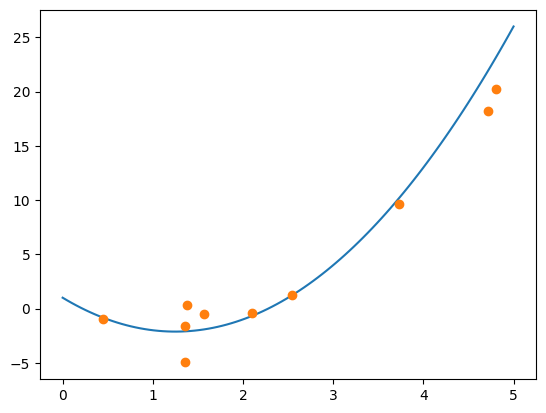

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.uniform(0, 5, 10)
y = 1-5*x+2*x**2
n_y = np.random.normal(0,np.sqrt(np.abs(y)))
y = y + n_y

x2 = np.linspace(0,5,100)
y2 = 1-5*x2+2*x2**2


plt.plot(x2,y2)
plt.plot(x,y,'o')
plt.show()



To fit the quadratic model need to build the matrix with $x^2$ in the appropriate column
before calling the least squares function:

In [8]:
N = 10

#now build the matrix
A = np.ones((N,3))
for i in range(N):
    A[i,1] = x[i]
    A[i,2] = x[i]**2
solution = np.linalg.lstsq(A,y)[0]
print("The function is y =",solution[0],"+",
solution[1],"* x","+",solution[2],"* x^2")

The function is y = 0.04759801331862351 + -3.4423562461287007 * x + 1.5749176893960852 * x^2


The function is y = 1.8586328912410166 + -5.27068312690959 * x + 1.9930880346621027 * x^2


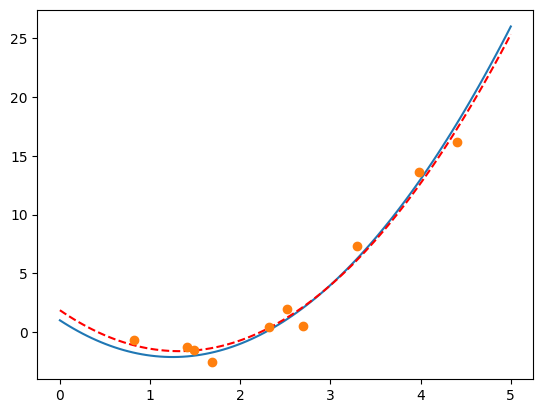

In [30]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.uniform(0, 5, 10)
y = 1-5*x+2*x**2
n_y = np.random.normal(0,np.sqrt(np.abs(y)))
y = y + n_y

x2 = np.linspace(0,5,100)
y2 = 1-5*x2+2*x2**2


N = 10

#now build the matrix
A = np.ones((N,3))
for i in range(N):
    A[i,1] = x[i]
    A[i,2] = x[i]**2
solution = np.linalg.lstsq(A,y)[0]
print("The function is y =",solution[0],"+",
solution[1],"* x","+",solution[2],"* x^2")

y_hat = solution[0] + solution[1] * x2 + solution[2] * x2**2

plt.plot(x2,y2)
plt.plot(x2,y_hat,'--r')
plt.plot(x,y,'o')
plt.show()

If we wanted to fit more complicated polynomial models, we can do this by placing the
correct powers of the independent variables in the data matrix $X$. This makes the least squares
curve fitting process very flexible.
We can also fit non-polynomial models such as

$$ f (x)= a + bx + csin x $$

In this case we have a column in the matrix that correspond to sin x. We will demonstrate this
with data produced from the function $y= 1− 0.5x + 3 sin x$ with added noise:

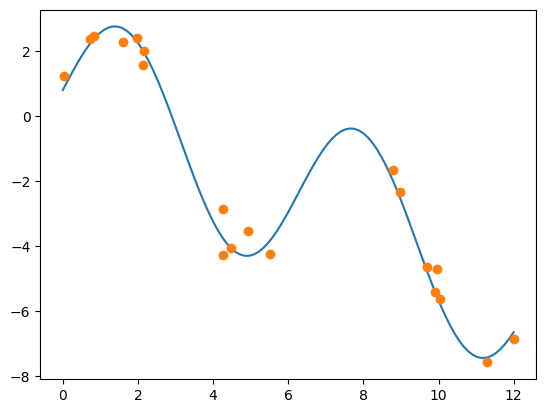

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.uniform(0, 12, 20)
y = 0.8 - 0.5*x + 2.7*np.sin(x)
n_y = np.random.normal(0,np.sqrt(np.abs(y)))
y = y + 0.25*n_y

x2 = np.linspace(0,12,100)
y2 = 0.8 - 0.5*x2 + 2.7*np.sin(x2)


plt.plot(x2,y2)
plt.plot(x,y,'o')
plt.show()

To fit this model we place the sine of $x$ in the appropriate column of the data matrix and
solve using least squares, as shown next:

The function is y = 0.7768416866875142 + -0.5257159443866343 * x + 2.678856135463639 * sin(x)


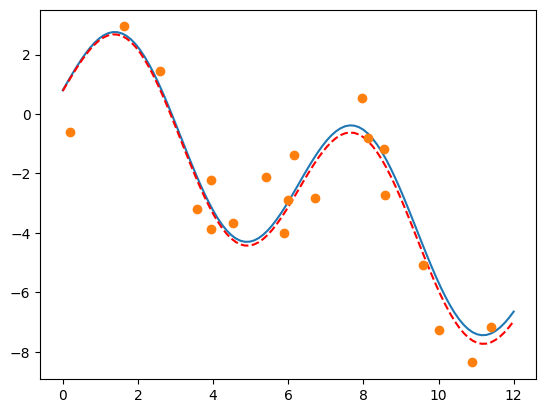

In [33]:
import numpy as np
import matplotlib.pyplot as plt

N = 20

x = np.random.uniform(0, 12, N)
y = 0.8 - 0.5*x + 2.7*np.sin(x)
#n_y = np.random.normal(0,np.sqrt(np.abs(y)))
#y = y + 0.25*n_y

y = np.random.normal(y)

x2 = np.linspace(0,12,100)
y2 = 0.8 - 0.5*x2 + 2.7*np.sin(x2)



#now build the matrix
A = np.ones((N,3))
for i in range(N):
    A[i,1] = x[i]
    A[i,2] = np.sin(x[i])

solution = np.linalg.lstsq(A,y)[0]
print("The function is y =",solution[0],"+",
solution[1],"* x","+",solution[2],"* sin(x)")

y_hat = solution[0] + solution[1] * x2 + solution[2] * np.sin(x2)

plt.plot(x2,y2)
plt.plot(x2,y_hat,'--r')
plt.plot(x,y,'o')
plt.show()

In this example with the sine function, the least squares regression model does a good job
of finding the underlying model coefficients. Despite there being some data points far away
from the actual function due to noise, the model fit is very close to the actual model used to
generate the data.

## 11.4 Exponential Models: The Logarithmic Transform

Beyond nonlinear transformations to independent variables, we can use logarithms to fit
models that are exponentials or power laws of independent variables. A particularly relevant example would be fitting a model to determine the half-life of a radioactive sample:

$$
A(t) = A_0 e^{-\lambda t}
$$

$$
\lambda = \frac{\ln 2}{T_{1/2}}.
$$

where A is the activity. To fit this model we can take the natural logarithm of both sides and
find

$$
\ln A(t) = \ln A_0 - \lambda t.
$$

Therefore, if we fit a model where the dependent variable (i.e., the left-hand side) is the natural logarithm of $f(x)$, then we can infer both the half-life and the initial activity.

As before, we will generate data from a known exponential and add noise to the data points. In this case, we generate decay data from a sample of $10^{12}$ atoms of arsenic-76, which has a half-life $1.09379 \pm 0.00045$ days.



The inital activity is A_0 = 1000001073272.7021 and the half-life is 1.0937891511655247 days.


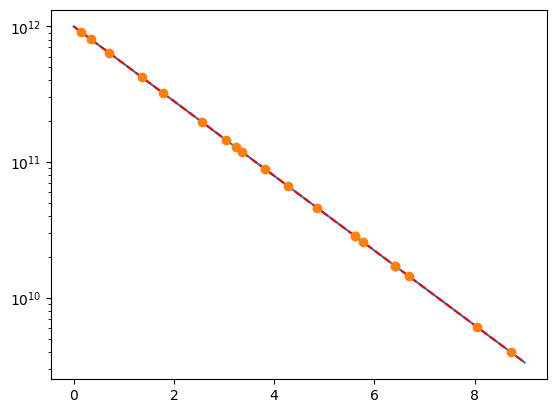

In [39]:
import numpy as np
import matplotlib.pyplot as plt

N = 20
A0 = 1e12

t = np.random.uniform(0, 9, N)
activity = A0*np.exp(-np.log(2)/1.09379*t)
activity = np.random.poisson(activity)

t2 = np.linspace(0,9,100)
a2 = A0*np.exp(-np.log(2)/1.09379*t2)

#now build the matrix
A = np.ones((N,2))
for i in range(N):
    A[i,1] = t[i]

# print("The A matrix is\n",A)
solution = np.linalg.lstsq(A,np.log(activity))[0]
print("The inital activity is A_0 =",np.exp(solution[0]),
"and the half-life is",-np.log(2)/solution[1],"days.")


a_hat = np.exp(solution[0] + solution[1] * t2)

plt.semilogy(t2,a2)
plt.semilogy(t2,a_hat,'--r')
plt.semilogy(t,activity,'o')
plt.show()

### 11.4.1 Power Law Models

It is also possible fit power-law models using similar manipulations. The function

$$
f(x) = a x^b
$$

can be transformed to a linear, additive model by writing a function

$$
\ln f(x) = \ln a + b \ln(x)
$$


That is, we take the natural logarithm of $x$ and $f(x)$ to obtain a linear function. Such power laws appear in many kinds of natural data.

One, perhaps unexpected, place a power law appears is in the number of words used with a given frequency in language. In English, it has been conjectured that the 100 most common words make up 50% of all writing. Another way to view this is that there are a small number of words that are used very frequently (e.g., the, a, and, etc.), and many words that are used very infrequently (e.g., consanguine or antiderivative).

Therefore, if we examine any work of literature, we expect there to be thousands of words used only one or two times, and a few words used thousands of times. To demonstrate this, we can look at the word frequency distribution for the venerable work of literature *Moby Dick*. The next figure is a histogram of word frequency in *Moby Dick*. For example, there are approximately $10^4$ words that are used only once in the book, out of the 17,227 unique words in the text.



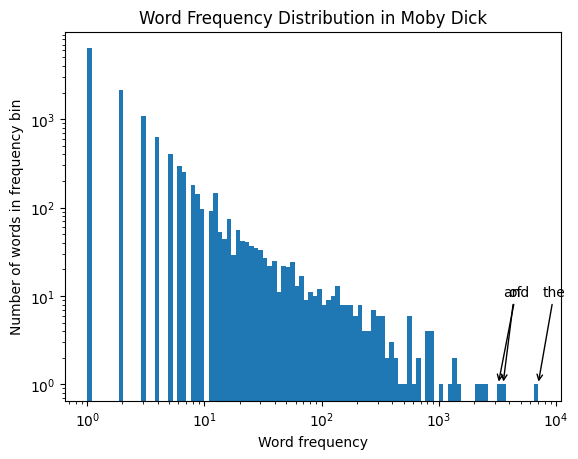

In [6]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- Load and tokenize ---
with open("mobydick.txt", "r", encoding="utf-8", errors="ignore") as f:
    text = f.read().lower()

text = re.sub(r"[^a-z\s]", " ", text)
words = [w for w in text.split() if w.isalpha()]

freq = Counter(words)

# word frequencies (counts per unique word)
counts = np.array(list(freq.values()))

# --- Log-spaced bins (equal width in log10 space) ---
log_counts = np.log10(counts)
log_edges = np.linspace(log_counts.min(), log_counts.max(), 101)  # 100 bins
edges = 10 ** log_edges  # convert back to linear frequency

# histogram: number of unique words per frequency bin
hist, edges = np.histogram(counts, bins=edges)

# geometric midpoints for log x-axis
mid = np.sqrt(edges[:-1] * edges[1:])

# --- Plot (log-log) ---
plt.figure()
plt.bar(mid, hist, width=(edges[1:] - edges[:-1]), align="center")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Word frequency")
plt.ylabel("Number of words in frequency bin")
plt.title("Word Frequency Distribution in Moby Dick")

# --- Annotate a few common words (optional) ---
top_words = ["the", "of", "and"]
for w in top_words:
    if w in freq:
        plt.annotate(
            w,
            xy=(freq[w], 1), xycoords="data",
            xytext=(freq[w]*1.1, 10), textcoords="data",
            arrowprops=dict(arrowstyle="->"),
        )

plt.show()


The word “the” was used over $10{,}000$ times.

For this data, we want to fit a model of the form

$$
\text{Number of words with a given frequency}
= a \, (\text{Word Frequency})^{b}.
$$

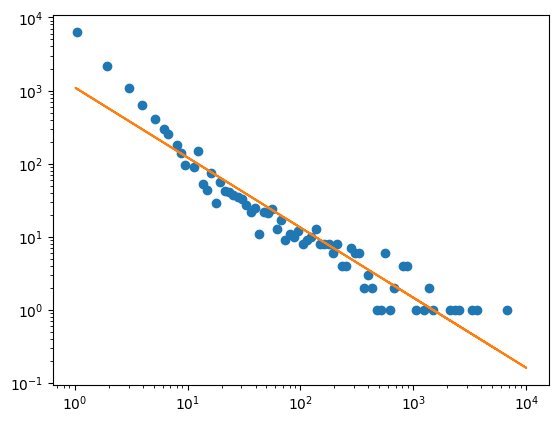

In [22]:
# mid, hist

data = np.column_stack((mid, hist))

data = data[data[:, 1] != 0]

mid = data[:,0]
hist = data[:,1]

N = np.size(mid)

#now build the matrix
A = np.ones((N,2))
for i in range(N):
    A[i,1] = np.log(mid[i])

# print("The A matrix is\n",A)
solution = np.linalg.lstsq(A,np.log(hist))[0]

x = np.random.uniform(1,10000,100000)
y_hat = np.exp(solution[0])*x**solution[1]


plt.loglog(mid, hist, 'o')
plt.loglog(x,y_hat)



